###### Patricia Clarji 202500382 | Marie-Lie kadado 202402112

# Diabetes Readmission Prediction

## Objectives
- **Multiclass Classification:** Predict the patient's readmission category (`readmitted`: NO, >30, <30)
- **Regression:** Predict time spent in hospital (`time_in_hospital`)

**Dataset:** Diabetes 130-US Hospitals Dataset (1999–2008, 130 US hospitals)

### Project Description

Hospital readmissions are costly and may indicate complications in patient care.
The goal of this project is to analyze hospital records of diabetic patients and build machine learning models for:

- **Multiclass classification:** predict the patient's readmission category (`NO`, `>30`, `<30`)
- **Regression:** predict the patient's length of stay in the hospital (`time_in_hospital`)

### Step 1 — Import Libraries

In [66]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

### Step 2 — Load Dataset

In [67]:
#Config
DATA_PATH               = "../data/diabetes.csv"
CLASSIFICATION_TARGET   = "readmitted"
REGRESSION_TARGET       = "time_in_hospital"
RANDOM_STATE            = 42

In [68]:
df = pd.read_csv(DATA_PATH, na_values='?', low_memory=False)

# Split column types
numerical_cols   = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical columns :", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns : ['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
Categorical columns: ['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


C:\Users\lenovo\AppData\Local\Temp\ipykernel_63056\3373397226.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


### Step 3 — Dataset Overview

We inspect the dataset structure, data types, missing values, and descriptive statistics to understand the variables before preprocessing and modeling.

#### 3.1 Head (10 rows)

In [69]:
print("Dataset preview:")
display(df.head(10))

Dataset preview:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),NaN,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,[60-70),NaN,3,1,2,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,[70-80),NaN,1,1,7,5,...,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,[80-90),NaN,2,1,4,13,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),NaN,3,3,4,12,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


#### 3.2 Info

In [70]:
print("\nDataset info:")
df.info()


Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      99493 non-null   str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    3197 non-null    str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                61510 non-null   str  
 11  medical_specialty         51817 non-null   str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications 

#### 3.3 Missing Values

In [71]:
print("\nMissing values per column:")
display(df.isnull().sum().sort_values(ascending=False))


Missing values per column:


weight                      98569
max_glu_serum               96420
A1Cresult                   84748
medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
patient_nbr                     0
time_in_hospital                0
admission_source_id             0
num_lab_procedures              0
encounter_id                    0
admission_type_id               0
discharge_disposition_id        0
gender                          0
age                             0
number_inpatient                0
number_emergency                0
number_outpatient               0
num_medications                 0
num_procedures                  0
number_diagnoses                0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

#### 3.4 Numerical Summary

In [72]:
print("\nNumerical summary:")
display(df[numerical_cols].describe().round(2))


Numerical summary:


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00
mean,1.652016e+08,5.433040e+07,2.02,3.72,5.75,4.40,43.10,1.34,16.02,0.37,0.20,0.64,7.42
std,1.026403e+08,3.869636e+07,1.45,5.28,4.06,2.99,19.67,1.71,8.13,1.27,0.93,1.26,1.93
min,1.252200e+04,1.350000e+02,1.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00
25%,8.496119e+07,2.341322e+07,1.00,1.00,1.00,2.00,31.00,0.00,10.00,0.00,0.00,0.00,6.00
50%,1.523890e+08,4.550514e+07,1.00,1.00,7.00,4.00,44.00,1.00,15.00,0.00,0.00,0.00,8.00
75%,2.302709e+08,8.754595e+07,3.00,4.00,7.00,6.00,57.00,2.00,20.00,0.00,0.00,1.00,9.00
max,4.438672e+08,1.895026e+08,8.00,28.00,25.00,14.00,132.00,6.00,81.00,42.00,76.00,21.00,16.00


#### 3.5 Categorical Summary

In [73]:
print("\nCategorical summary:")
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False))
    print("-" * 40)


Categorical summary:

Column: race
race
Caucasian          76099
AfricanAmerican    19210
NaN                 2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64
----------------------------------------

Column: gender
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64
----------------------------------------

Column: age
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64
----------------------------------------

Column: weight
weight
NaN          98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64
----------------------------------------

Column: payer_code
payer_code
Na

#### 3.6 Shape & Column Counts

In [74]:
print("Shape of dataset:", df.shape)
print("Number of numeric columns:", len(numerical_cols))
print("Number of categorical columns:", len(categorical_cols))
print("Classification target:", CLASSIFICATION_TARGET)
print("Regression target:", REGRESSION_TARGET)

Shape of dataset: (101766, 50)
Number of numeric columns: 13
Number of categorical columns: 37
Classification target: readmitted
Regression target: time_in_hospital


### Step 4 — Exploratory Data Analysis (EDA)

In this step we explore the dataset using visualizations to identify patterns, trends, and relationships between variables.

#### 4.0 Visualization Setup

In [75]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize"   : (9, 5),
    "axes.titleweight" : "bold",
    "axes.titlesize"   : 13,
    "axes.labelsize"   : 11,
})

PALETTE        = "Set2"
readmit_order  = ['NO', '>30', '<30']
age_order      = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
                  '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
corr_cols      = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses'
]

#### 4.1 Target Variable Analysis

We analyse both target variables: `readmitted` (classification) and `time_in_hospital` (regression).

##### A — Readmission Distribution (with Class-Imbalance %)

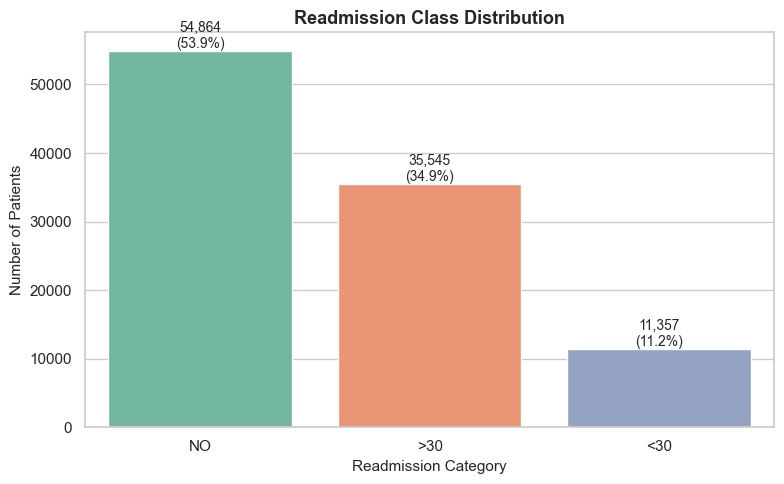

In [76]:
fig, ax = plt.subplots(figsize=(8, 5))

counts = df['readmitted'].value_counts()[readmit_order]
total  = counts.sum()
bars   = sns.barplot(x=counts.index, y=counts.values, order=readmit_order,
                palette=PALETTE, ax=ax)

for p in bars.patches:
        h = p.get_height()
        ax.annotate(f'{int(h):,}\n({h/total*100:.1f}%)',
                (p.get_x() + p.get_width()/2, h),
                ha='center', va='bottom', fontsize=10)

ax.set_title("Readmission Class Distribution", fontweight='bold')
ax.set_xlabel("Readmission Category")
ax.set_ylabel("Number of Patients")

plt.tight_layout()
plt.show()

**Interpretation:** Most patients (`NO` ≈ 54%) were not readmitted, while the `<30` class is the smallest. This class imbalance is important for model selection — we will use weighted F1-score as the primary metric and apply `class_weight='balanced'` where applicable.

##### B — Time in Hospital Distribution

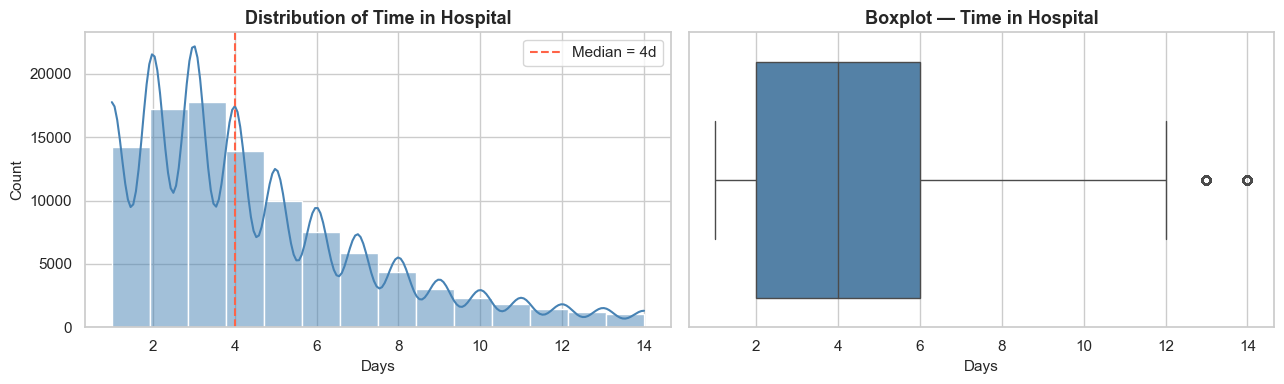

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram with KDE
sns.histplot(df['time_in_hospital'], kde=True, bins=14, ax=axes[0], color='steelblue')
axes[0].axvline(df['time_in_hospital'].median(), color='tomato', linestyle='--', label=f"Median = {df['time_in_hospital'].median():.0f}d")
axes[0].set_title("Distribution of Time in Hospital")
axes[0].set_xlabel("Days")
axes[0].set_ylabel("Count")
axes[0].legend()

# Boxplot
sns.boxplot(x=df['time_in_hospital'], ax=axes[1], color='steelblue')
axes[1].set_title("Boxplot — Time in Hospital")
axes[1].set_xlabel("Days")

plt.tight_layout()
plt.show()

**Interpretation:** Most stays peak between 3–4 days. The distribution is right-skewed with the median lower than the mean, and a few outliers indicating longer stays for complex cases. This skewness is relevant for regression — tree-based models will handle it better than linear approaches.

#### 4.2 Univariate Analysis

##### A — Numerical Features: Distribution + Outliers (Combined)

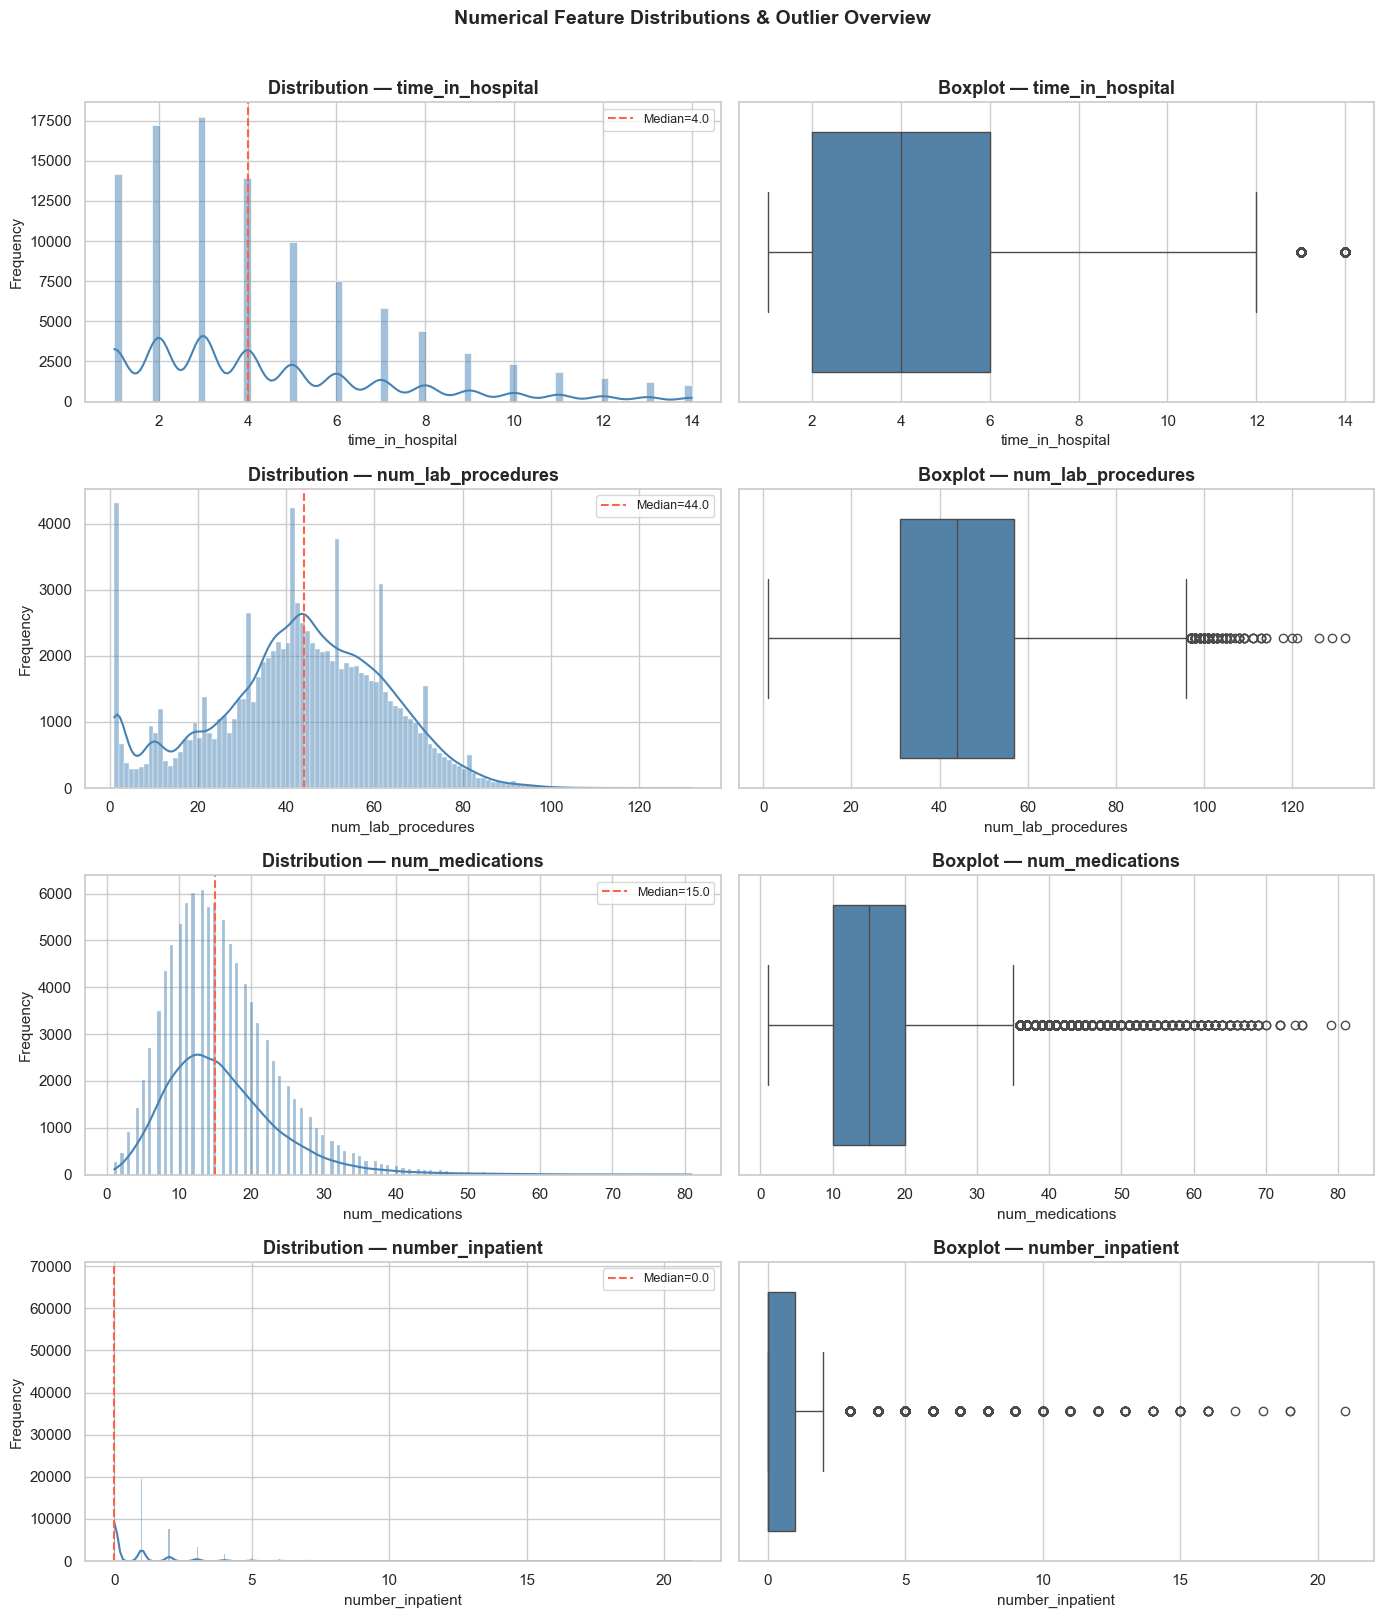

In [78]:
num_cols_eda = ['time_in_hospital', 'num_lab_procedures', 'num_medications', 'number_inpatient']

fig, axes = plt.subplots(len(num_cols_eda), 2, figsize=(14, 4 * len(num_cols_eda)))

for i, col in enumerate(num_cols_eda):
    # Histogram
    sns.histplot(data=df, x=col, kde=True, ax=axes[i, 0], color='steelblue')
    axes[i, 0].set_title(f"Distribution — {col}")
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel("Frequency")
    median_val = df[col].median()
    axes[i, 0].axvline(median_val, color='tomato', linestyle='--', label=f'Median={median_val:.1f}')
    axes[i, 0].legend(fontsize=9)

    # Boxplot
    sns.boxplot(data=df, x=col, ax=axes[i, 1], color='steelblue')
    axes[i, 1].set_title(f"Boxplot — {col}")
    axes[i, 1].set_xlabel(col)

plt.suptitle("Numerical Feature Distributions & Outlier Overview", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:** All numerical features are right-skewed, concentrated at lower values. Boxplots reveal outliers in all features. In a healthcare context, extreme values typically represent genuine severe cases (high inpatient visits, many medications) rather than data errors — they were retained to preserve clinical integrity. Robust tree-based models can handle these naturally.

##### B — Categorical Features Distribution

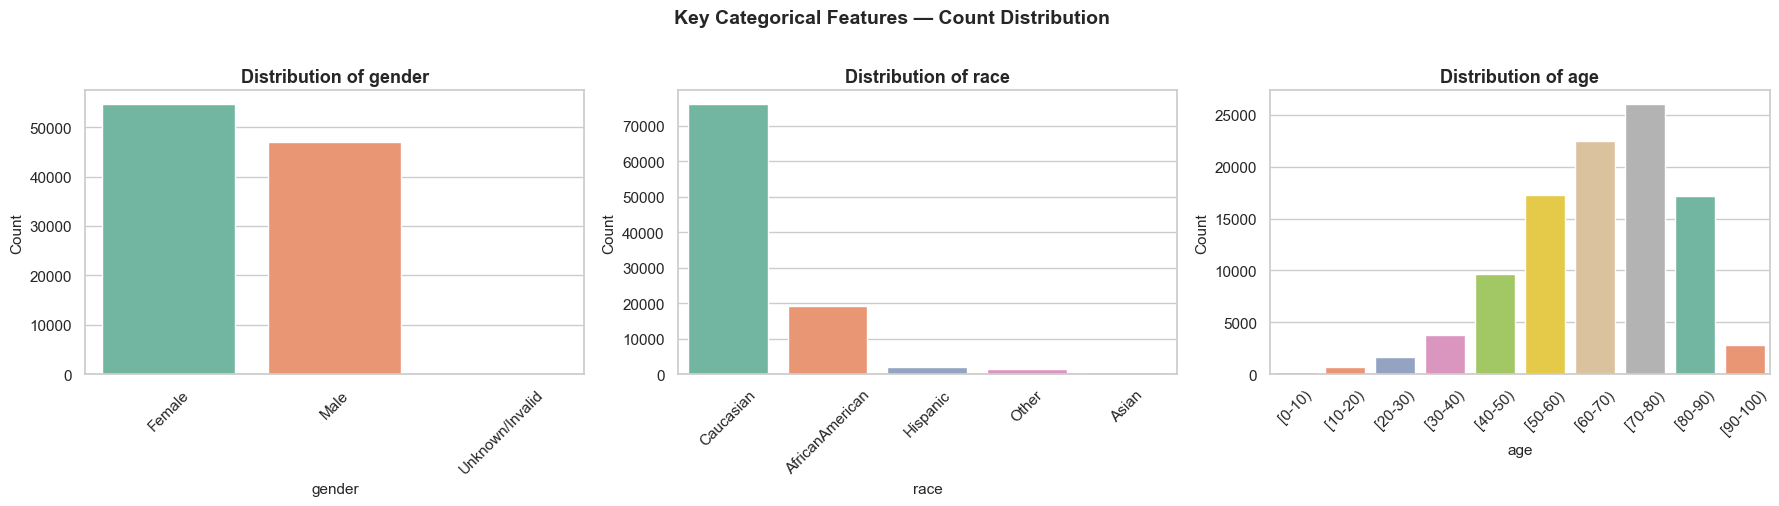

In [79]:
cat_cols_eda = ['gender', 'race', 'age']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(cat_cols_eda):
    order = age_order if col == 'age' else df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, palette=PALETTE, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle("Key Categorical Features — Count Distribution", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:** Caucasian patients dominate the race distribution, and patients aged 60–80 are most common — reflecting the typical demographics of diabetes in the US. The gender split is roughly even. These imbalances may affect model fairness and should be noted.

#### 4.3 Bivariate Analysis: Features vs Readmission

##### A — Age vs Readmission (Proportion Plot)

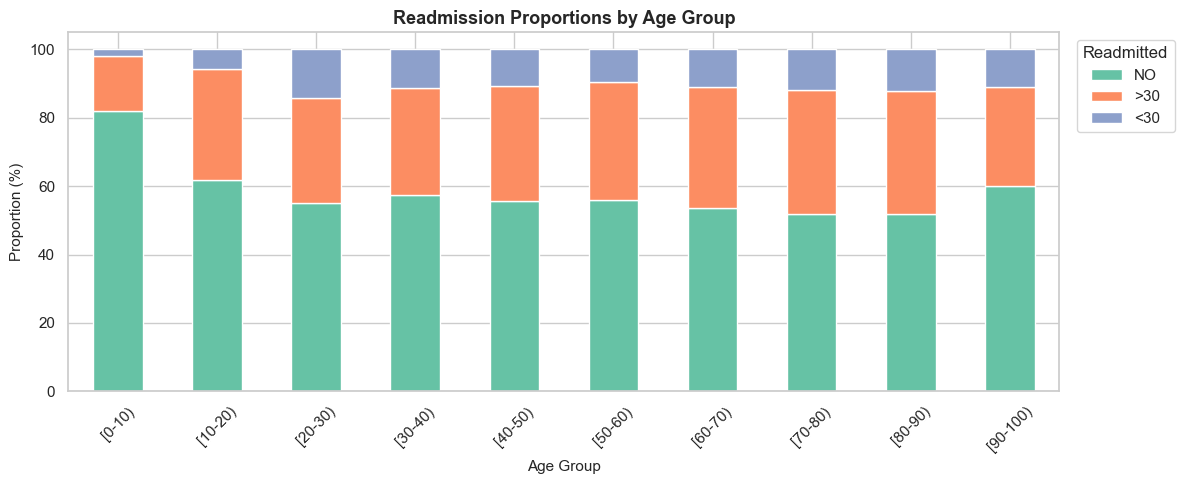

In [80]:
# Proportion-based stacked bar — avoids misleading raw-count differences
age_readmit = df.groupby(['age', 'readmitted']).size().unstack(fill_value=0)
age_readmit = age_readmit.loc[age_order]
age_readmit_pct = age_readmit.div(age_readmit.sum(axis=1), axis=0) * 100

age_readmit_pct[readmit_order].plot(
    kind='bar', stacked=True,
    color=sns.color_palette(PALETTE, 3),
    figsize=(12, 5), edgecolor='white'
)
plt.title("Readmission Proportions by Age Group", fontsize=13, fontweight='bold')
plt.xlabel("Age Group")
plt.ylabel("Proportion (%)")
plt.xticks(rotation=45)
plt.legend(title='Readmitted', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Interpretation:** The proportion stacked bars reveal that readmission rates are relatively stable across age groups, with a slight increase in early readmissions (`<30`) among older patients (70–90). Raw-count plots would be misleading due to age-group size differences, so proportions are used here.

##### B — Gender vs Readmission

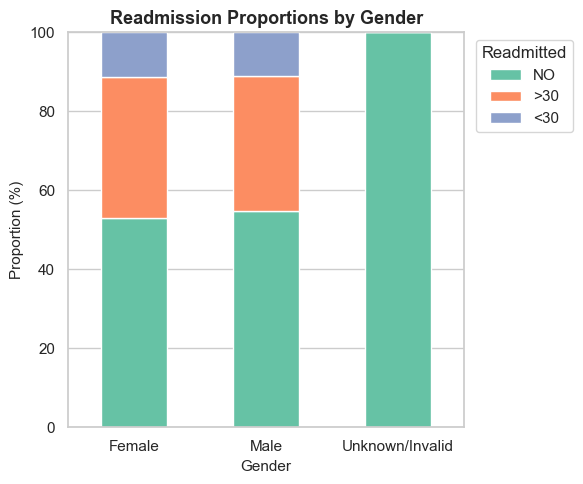

In [81]:
gender_readmit = df.groupby(['gender', 'readmitted']).size().unstack(fill_value=0)
gender_readmit_pct = gender_readmit.div(gender_readmit.sum(axis=1), axis=0) * 100

gender_readmit_pct[readmit_order].plot(
    kind='bar', stacked=True,
    color=sns.color_palette(PALETTE, 3),
    figsize=(6, 5), edgecolor='white'
)
plt.title("Readmission Proportions by Gender", fontsize=13, fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("Proportion (%)")
plt.xticks(rotation=0)
plt.legend(title='Readmitted', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Interpretation:** Proportions are nearly identical between Male and Female, confirming that gender alone is a weak predictor of readmission.

##### C — Clinical Markers vs Readmission (Measured Patients Only)

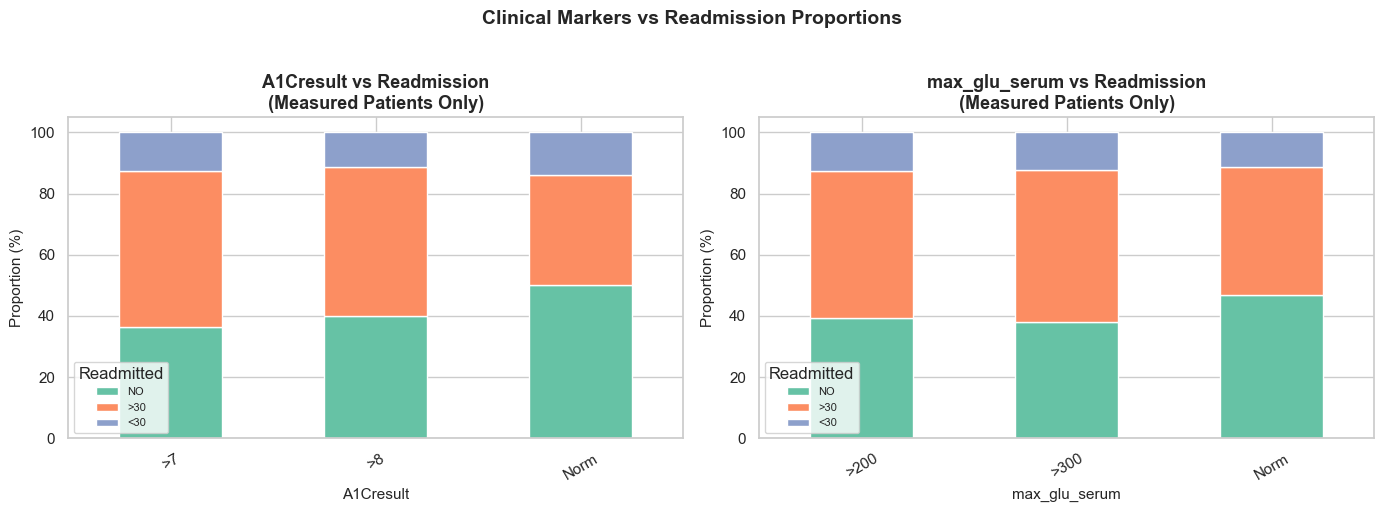

In [82]:
clinical_cols = ['A1Cresult', 'max_glu_serum']
df_clinical   = df[
    (df['A1Cresult']    != 'None') & (df['A1Cresult'].notna()) &
    (df['max_glu_serum']!= 'None') & (df['max_glu_serum'].notna())
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(clinical_cols):
    measured   = df_clinical[df_clinical[col] != 'NotMeasured']
    prop_table = (
        measured.groupby([col, 'readmitted'])
        .size().unstack(fill_value=0)
        .div(measured.groupby(col).size(), axis=0) * 100
    )
    # Keep columns that exist
    cols_present = [c for c in readmit_order if c in prop_table.columns]
    prop_table[cols_present].plot(
        kind='bar', stacked=True,
        color=sns.color_palette(PALETTE, len(cols_present)),
        edgecolor='white', ax=axes[i]
    )
    axes[i].set_title(f"{col} vs Readmission\n(Measured Patients Only)")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Proportion (%)")
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Readmitted', fontsize=8)

plt.suptitle("Clinical Markers vs Readmission Proportions", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:** Among patients with measured values, abnormal A1C (`>7` or `>8`) and elevated glucose results are associated with slightly higher readmission proportions. The majority of patients had these tests not measured, limiting the predictive power of these features.

##### D — Hospital Utilization vs Readmission

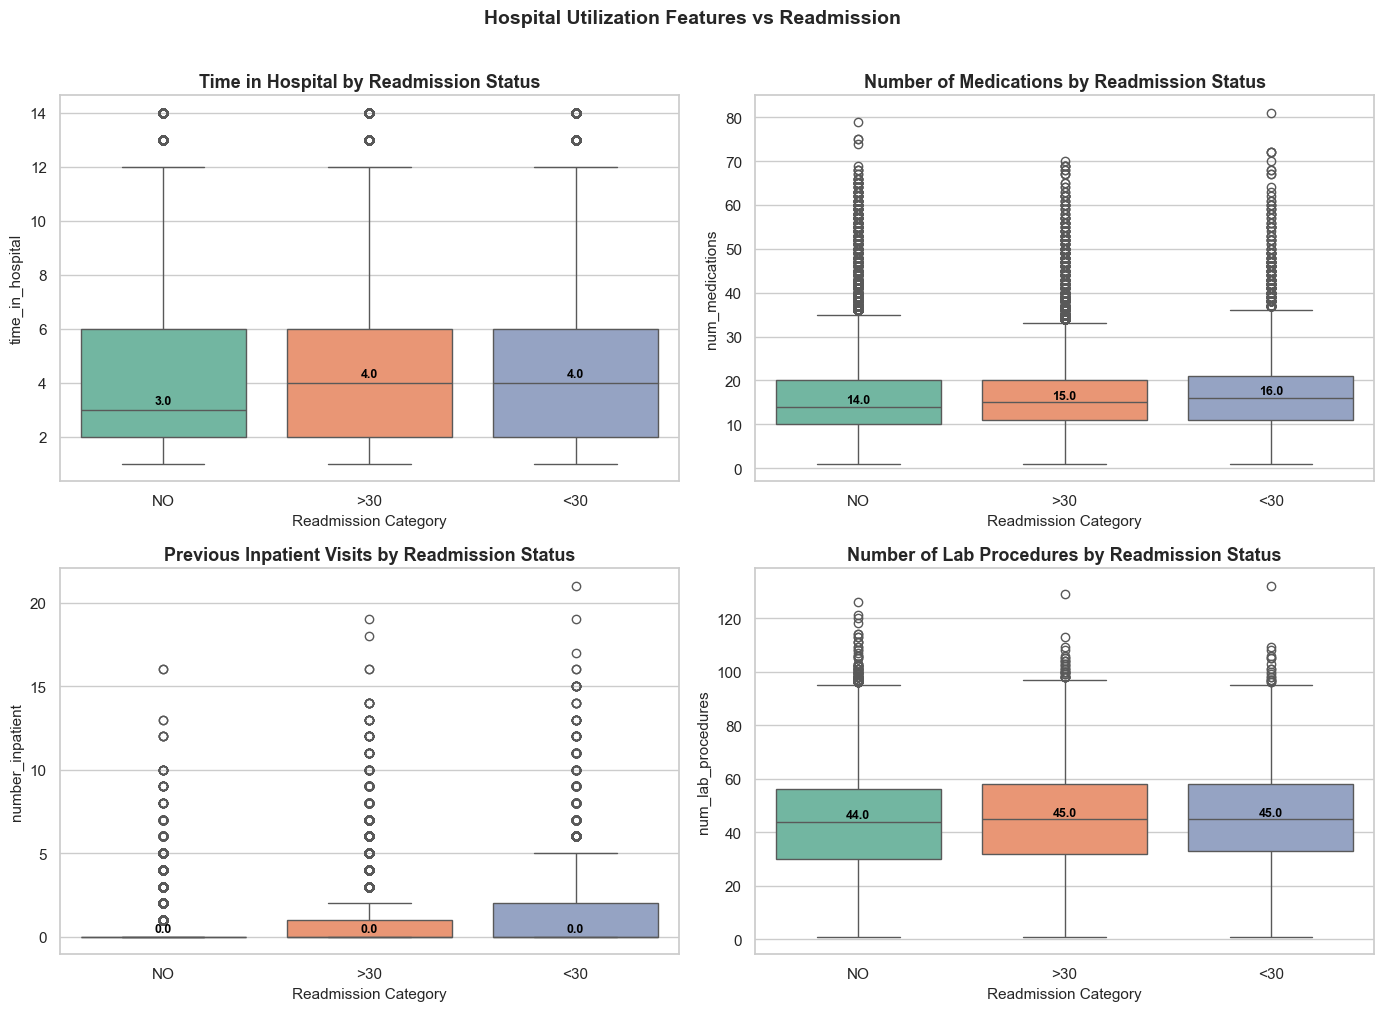

In [83]:
features = ['time_in_hospital', 'num_medications', 'number_inpatient', 'num_lab_procedures']
titles   = [
    "Time in Hospital", "Number of Medications",
    "Previous Inpatient Visits", "Number of Lab Procedures"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (col, title) in enumerate(zip(features, titles)):
    sns.boxplot(data=df, x='readmitted', y=col,
                order=readmit_order, palette=PALETTE, ax=axes[i])
    # Add median annotations
    for j, cat in enumerate(readmit_order):
        med = df.loc[df['readmitted'] == cat, col].median()
        axes[i].text(j, med + 0.1, f'{med:.1f}',
                    ha='center', va='bottom', fontsize=9, color='black', fontweight='bold')
    axes[i].set_title(f"{title} by Readmission Status")
    axes[i].set_xlabel("Readmission Category")
    axes[i].set_ylabel(col)

plt.suptitle("Hospital Utilization Features vs Readmission", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:** Patients readmitted within 30 days (`<30`) consistently show higher medians for hospital utilization metrics. Prior inpatient visits show the clearest separation, suggesting that patients with complex histories are most at risk. Median annotations make differences concrete.

#### 4.4 Missingness Overview

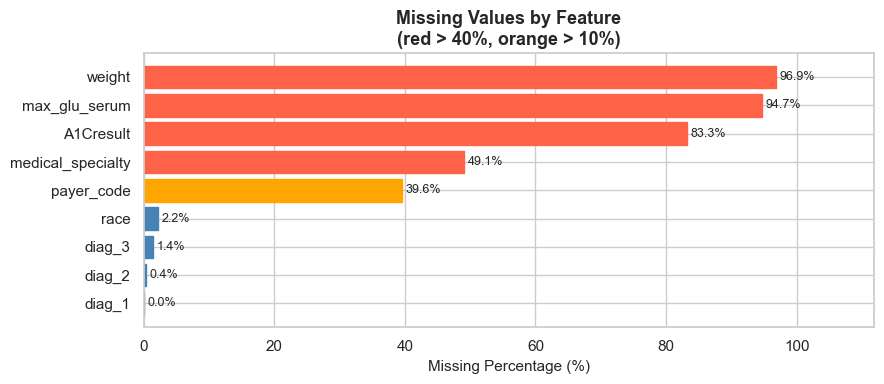

Columns with >40% missing (candidates for dropping):
weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208


In [84]:
missing_pct = df.isnull().mean().mul(100)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, max(4, len(missing_pct) * 0.4)))
bars = ax.barh(missing_pct.index, missing_pct.values, color='steelblue', edgecolor='white')

# Colour-code by severity
for bar, val in zip(bars, missing_pct.values):
    bar.set_color('tomato' if val > 40 else ('orange' if val > 10 else 'steelblue'))
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_xlabel("Missing Percentage (%)")
ax.set_title("Missing Values by Feature\n(red > 40%, orange > 10%)", fontweight='bold')
ax.set_xlim(0, missing_pct.max() + 15)
plt.tight_layout()
plt.show()

print("Columns with >40% missing (candidates for dropping):")
print(missing_pct[missing_pct > 40].sort_values(ascending=False).to_string())

#### 4.5 Numerical Feature Correlations

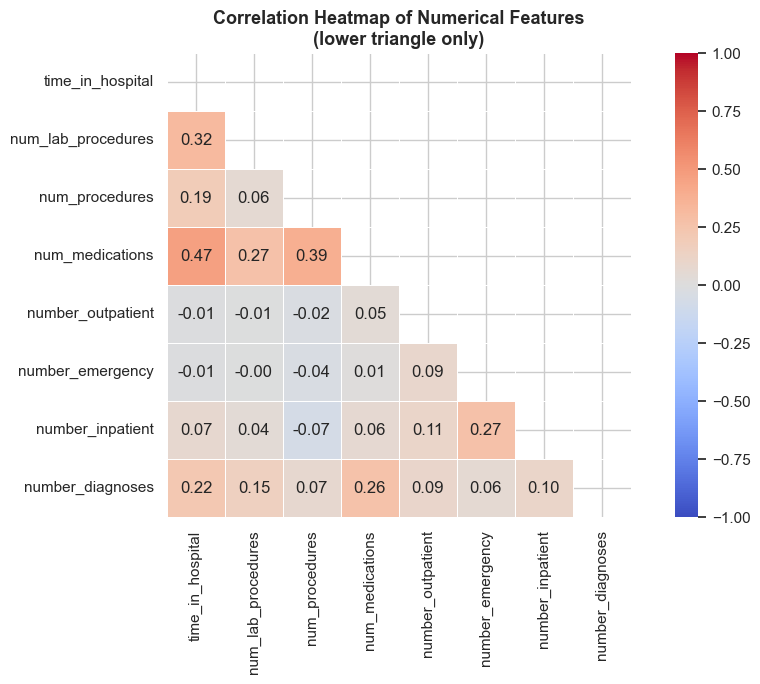

In [85]:
corr = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))   # upper-triangle mask (no duplicate)

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr, mask=mask,
    annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f",
    vmin=-1, vmax=1, square=True
)
plt.title("Correlation Heatmap of Numerical Features\n(lower triangle only)", fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** The heatmap (lower triangle only — no duplicated cells) shows moderate correlations among hospital-utilisation features. `num_lab_procedures` and `num_medications` share a moderate positive correlation (~0.4), reflecting treatment intensity. No extreme multicollinearity is present.

### Step 5 — Data Preprocessing

Data preprocessing prepares the dataset for machine learning by handling missing values, removing irrelevant features, encoding categorical variables, and scaling numerical features.

> **Important:** All preprocessing steps that could cause data leakage (e.g., encoding with training statistics, anomaly detection) are applied *after* the train/test split in the modelling sections, or are applied only to features that are independent of the target.

#### 5.1 Remove Duplicates

In [86]:
print("Duplicate rows before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicate rows after:", df.duplicated().sum())
print("Dataset shape after removing duplicates:", df.shape)

Duplicate rows before: 0
Duplicate rows after: 0
Dataset shape after removing duplicates: (101766, 50)


#### 5.2 Handle Missing Values

Different imputation strategies are used based on feature semantics:

| Strategy | Features | Rationale |
|---|---|---|
| `'Missing'` category | `race` | Absence is informative |
| `'NotMeasured'` category | `A1Cresult`, `max_glu_serum` | Not tested ≠ normal |
| `'No'` | Medication cols, `change`, `diabetesMed` | Missing = not prescribed |
| Median | Continuous numeric (skewed) | Robust to outliers |
| Zero | Count-based visit cols | Missing = no visits |
| Drop row | Target variable | Cannot predict without a label |

Rare race categories (`Asian`, `Hispanic`) are consolidated into `'Other'` to reduce sparsity.

In [87]:
# 1. Remove rows with missing target
df = df.dropna(subset=['readmitted'])

# 2. Race: keep missing as category, consolidate rare groups
df['race'] = df['race'].fillna('Missing').astype(str)
df['race'] = df['race'].replace({'Asian': 'Other', 'Hispanic': 'Other'})

# 3. Lab result columns: missing = NotMeasured
for col in ['max_glu_serum', 'A1Cresult']:
    df[col] = df[col].fillna('NotMeasured')

# 4. Medication columns: missing = not prescribed
medication_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]
for col in medication_cols:
    df[col] = df[col].fillna('No')

df['change']      = df['change'].fillna('No')
df['diabetesMed'] = df['diabetesMed'].fillna('No')

# 5. Hospital code columns as categorical (they are ID codes, not ordinal numbers)
for col in ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']:
    df[col] = df[col].astype(str)

# 6. Numeric columns
median_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
               'num_medications', 'number_diagnoses']
zero_cols   = ['number_outpatient', 'number_emergency', 'number_inpatient']

for col in median_cols:
    df[col] = df[col].fillna(df[col].median())
for col in zero_cols:
    df[col] = df[col].fillna(0)

print("Remaining missing values:")
display(df.isnull().sum().sort_values(ascending=False).head(20))

Remaining missing values:


weight                      98569
medical_specialty           49949
payer_code                  40256
diag_3                       1423
diag_2                        358
diag_1                         21
admission_type_id               0
encounter_id                    0
patient_nbr                     0
race                            0
time_in_hospital                0
admission_source_id             0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
discharge_disposition_id        0
gender                          0
age                             0
number_inpatient                0
number_emergency                0
dtype: int64

#### 5.3 Drop High-Missing & Irrelevant Columns

`weight` (97% missing), `payer_code` (40% missing), and `medical_specialty` (49% missing) are dropped.
`diag_1`, `diag_2`, `diag_3` are high-cardinality ICD-code fields requiring specialist grouping — excluded for this project.

In [88]:
cols_to_drop = ['weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3']
df.drop(columns=cols_to_drop, inplace=True)
print("Dataset shape after dropping columns:", df.shape)

Dataset shape after dropping columns: (101766, 44)


#### 5.4 Clean Invalid Gender Values

In [89]:
print("Gender values before cleaning:")
print(df['gender'].value_counts(dropna=False))
df = df[df['gender'].isin(['Male', 'Female'])]
print("\nGender values after cleaning:")
print(df['gender'].value_counts(dropna=False))

Gender values before cleaning:
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

Gender values after cleaning:
gender
Female    54708
Male      47055
Name: count, dtype: int64


#### 5.5 Check Multiclass Target Distribution

In [90]:
print("Readmission classes:")
print(df['readmitted'].value_counts(dropna=False))

Readmission classes:
readmitted
NO     54861
>30    35545
<30    11357
Name: count, dtype: int64


#### 5.6 Convert Age Groups to Ordinal Numeric Values

In [91]:
age_map = {
    '[0-10)': 5,  '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75,
    '[80-90)': 85, '[90-100)': 95
}
df['age_numeric'] = df['age'].map(age_map)
display(df[['age', 'age_numeric']].head())
df = df.drop(columns=['age'])

,age,age_numeric
0,[0-10),5
1,[10-20),15
2,[20-30),25
3,[30-40),35
4,[40-50),45


#### 5.7 Final Missing Values Check

In [92]:
print("Remaining missing values:")
display(df.isnull().sum().sort_values(ascending=False).head(20))

Remaining missing values:


encounter_id                0
patient_nbr                 0
race                        0
gender                      0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
dtype: int64

#### 5.8 Feature Engineering

New features summarise patient healthcare usage and treatment intensity:

| Feature | Formula | Rationale |
|---|---|---|
| `total_visits` | inpatient + emergency + outpatient | Overall healthcare burden |
| `total_procedures` | num_procedures + num_lab_procedures | Procedure intensity |

**Deduplication:** Only the **last encounter** per patient is retained to prevent patient-level data leakage — the same patient appearing in both train and test splits would inflate evaluation metrics. The last encounter is chosen as it reflects the most recent clinical state.

**Medication simplification:** Only `insulin` is kept; the remaining individual medication columns have negligible predictive signal when modelled individually and their removal reduces dimensionality.

In [93]:
# Engineered features
df['total_visits']     = df['number_inpatient'] + df['number_emergency'] + df['number_outpatient']
df['total_procedures'] = df['num_procedures'] + df['num_lab_procedures']

# Keep only the last encounter per patient (anti-leakage deduplication)
df = df.sort_values(by=['patient_nbr', 'encounter_id'])
df = df.drop_duplicates(subset='patient_nbr', keep='last')
df = df.drop(columns=['encounter_id', 'patient_nbr'])

# Drop low-signal individual medication columns, keep insulin
med_cols_to_drop = [col for col in df.columns
                    if col not in ['insulin'] and col in [
                        'metformin','repaglinide','nateglinide','chlorpropamide',
                        'glimepiride','acetohexamide','glipizide','glyburide',
                        'tolbutamide','pioglitazone','rosiglitazone','acarbose',
                        'miglitol','troglitazone','tolazamide','examide',
                        'citoglipton','glyburide-metformin','glipizide-metformin',
                        'glimepiride-pioglitazone','metformin-rosiglitazone',
                        'metformin-pioglitazone'
                    ]]
df = df.drop(columns=med_cols_to_drop)

print("Shape after feature engineering:", df.shape)
print("Columns:", list(df.columns))

Shape after feature engineering: (71515, 22)
Columns: ['race', 'gender', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'insulin', 'change', 'diabetesMed', 'readmitted', 'age_numeric', 'total_visits', 'total_procedures']


#### 5.9 Anomaly Detection

Isolation Forest identifies multivariate outliers (statistical anomalies) — distinct from clinical outliers discussed in the outlier-handling section.

**Key notes:**
- Applied **only to numerical features** (categorical columns excluded).
- Fitted on the **full cleaned dataset before splitting** — this is acceptable because anomaly detection is an unsupervised cleaning step that does not use the target label, and removing detected anomalies before splitting ensures both train and test are clean.
- 5% contamination is used, meaning the most extreme 5% of numerical patterns are treated as anomalies.
- Removed anomalies are logged before dropping.

In [94]:
# Anomaly detection on numerical features only (no target, no categorical)
X_anomaly = df.select_dtypes(include=['int64', 'float64']).drop(
    columns=[REGRESSION_TARGET], errors='ignore'
)

scaler_iso = StandardScaler()
X_scaled   = scaler_iso.fit_transform(X_anomaly)

iso         = IsolationForest(contamination=0.05, random_state=RANDOM_STATE)
df['anomaly'] = iso.fit_predict(X_scaled)

n_anomalies = (df['anomaly'] == -1).sum()
print(f"Anomalies detected: {n_anomalies} ({n_anomalies/len(df)*100:.1f}% of records)")

df = df[df['anomaly'] == 1].drop(columns=['anomaly'])
print(f"Dataset shape after anomaly removal: {df.shape}")

Anomalies detected: 3576 (5.0% of records)
Dataset shape after anomaly removal: (67939, 22)


#### 5.10 Feature Correlation with Target

We compute per-feature correlation with the encoded classification target to understand predictive signal. This analysis is purely exploratory — no features are dropped solely on correlation, as tree models can exploit non-linear relationships.

,Feature,|Correlation|
19,total_visits,0.169380
11,number_inpatient,0.154903
12,number_diagnoses,0.103330
6,num_lab_procedures,0.082633
20,total_procedures,0.080742
9,number_outpatient,0.072979
10,number_emergency,0.061037
18,age_numeric,0.059349
17,diabetesMed,0.048702
8,num_medications,0.043069


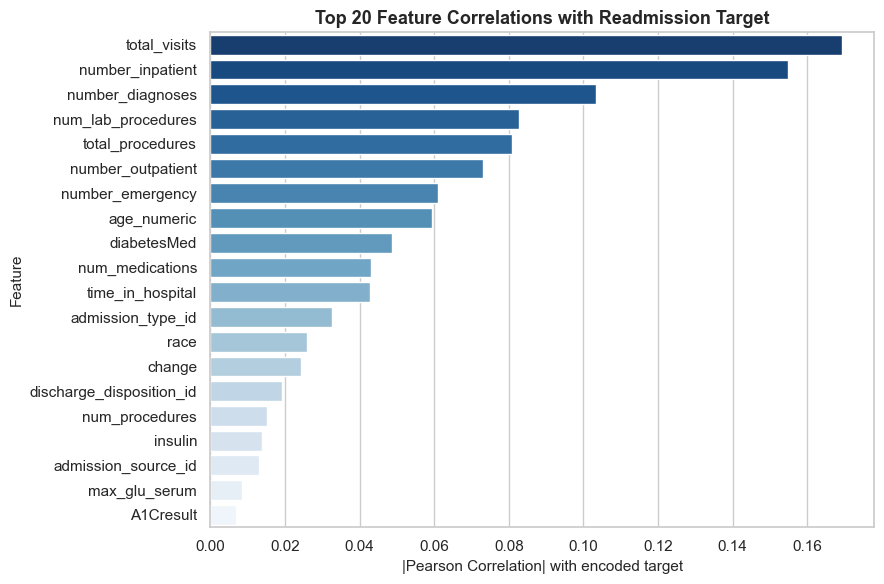

In [95]:
df_corr   = df.copy()
target_map = {'NO': 0, '>30': 1, '<30': 2}
df_corr['readmitted_num'] = df_corr['readmitted'].map(target_map)

results_corr = []
for col in df_corr.columns:
    if col in ['readmitted', 'readmitted_num']:
        continue
    try:
        if pd.api.types.is_numeric_dtype(df_corr[col]):
            c = abs(df_corr[col].corr(df_corr['readmitted_num']))
        else:
            temp = pd.get_dummies(df_corr[col], drop_first=True)
            c    = temp.corrwith(df_corr['readmitted_num']).abs().mean()
        results_corr.append((col, c))
    except Exception as e:
        print(f"Skipping {col}: {e}")

corr_df = (pd.DataFrame(results_corr, columns=['Feature', '|Correlation|'])
            .dropna()
            .sort_values('|Correlation|', ascending=False))

display(corr_df)

# Visualise top 20
top20 = corr_df.head(20)
plt.figure(figsize=(9, 6))
sns.barplot(data=top20, x='|Correlation|', y='Feature', palette='Blues_r')
plt.title("Top 20 Feature Correlations with Readmission Target", fontweight='bold')
plt.xlabel("|Pearson Correlation| with encoded target")
plt.tight_layout()
plt.show()

**Interpretation:** Hospital utilisation features (`number_inpatient`, `number_emergency`, `total_visits`) show the strongest associations with readmission. Demographic and most medication features have weak individual correlations. Non-linear models such as Random Forest may still utilise them through feature interactions.

#### 5.11 Preprocessing Summary

In [96]:
print("Final dataset shape:", df.shape)
print("Remaining missing values total:", df.isnull().sum().sum())
print("\nFinal columns:")
for col in df.columns:
    print(f"  {col:40s}  dtype={df[col].dtype}")

Final dataset shape: (67939, 22)
Remaining missing values total: 0

Final columns:
  race                                      dtype=str
  gender                                    dtype=str
  admission_type_id                         dtype=str
  discharge_disposition_id                  dtype=str
  admission_source_id                       dtype=str
  time_in_hospital                          dtype=int64
  num_lab_procedures                        dtype=int64
  num_procedures                            dtype=int64
  num_medications                           dtype=int64
  number_outpatient                         dtype=int64
  number_emergency                          dtype=int64
  number_inpatient                          dtype=int64
  number_diagnoses                          dtype=int64
  max_glu_serum                             dtype=str
  A1Cresult                                 dtype=str
  insulin                                   dtype=str
  change                             

### Step 6 — Multiclass Classification

We build models to predict the readmission category (`readmitted`: NO / >30 / <30).

#### 6.0 Import Classification Libraries

In [97]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay)
import pickle

#### 6.1 Prepare Features and Target

`readmitted_binary` is **not** created here — it will be created inside its own section from `y_clf` to avoid any leakage into `X_clf`.

In [98]:
y_clf = df["readmitted"]
X_clf = df.drop(columns=["readmitted", "time_in_hospital"])

print("Feature matrix shape:", X_clf.shape)
print("Target shape:", y_clf.shape)
print("\nTarget distribution:")
print(y_clf.value_counts())

Feature matrix shape: (67939, 20)
Target shape: (67939,)

Target distribution:
readmitted
NO     52256
>30    12804
<30     2879
Name: count, dtype: int64


#### 6.2 Train-Test Split

The split is performed **before** any encoding or scaling. This ensures that no information from the test set contaminates preprocessing steps.

In [99]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_clf          # preserve class proportions
)

print("Training set:", X_train_clf.shape)
print("Testing set :", X_test_clf.shape)

Training set: (54351, 20)
Testing set : (13588, 20)


#### 6.3 Encode Categorical Features (Post-Split — No Leakage)

Encoding is performed **after** the split:
- Binary/ordinal columns mapped using fixed dictionaries (no training statistics → no leakage).
- One-Hot Encoding fitted on **training data only**, then applied to test data via `.align()`.
- `admission_type_id`, `discharge_disposition_id`, `admission_source_id` are ID codes treated as categorical integers.

In [100]:
def encode_clf(X_train, X_test):
    """Encode categorical features. Must be called with (train, test) pair."""
    import copy
    X_tr = X_train.copy()
    X_te = X_test.copy()

    # Binary / ordinal mappings (fixed — no leakage)
    binary_maps = {
        'change'      : {'No': 0, 'Ch': 1},
        'diabetesMed' : {'No': 0, 'Yes': 1},
        'insulin'     : {'No': 0, 'Steady': 1, 'Up': 2, 'Down': 3},
    }
    for col, mapping in binary_maps.items():
        if col in X_tr.columns:
            X_tr[col] = X_tr[col].map(mapping)
            X_te[col] = X_te[col].map(mapping)

    # ID codes → integer
    for col in ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']:
        if col in X_tr.columns:
            X_tr[col] = X_tr[col].astype(int)
            X_te[col] = X_te[col].astype(int)

    # One-Hot Encoding on training split only, then align test
    ohe_cols = ['race', 'gender', 'A1Cresult', 'max_glu_serum']
    ohe_cols = [c for c in ohe_cols if c in X_tr.columns]
    X_tr = pd.get_dummies(X_tr, columns=ohe_cols, drop_first=True)
    X_te = pd.get_dummies(X_te, columns=ohe_cols, drop_first=True)
    X_tr, X_te = X_tr.align(X_te, join='left', axis=1, fill_value=0)

    return X_tr, X_te

X_train_clf, X_test_clf = encode_clf(X_train_clf, X_test_clf)

print("Remaining object columns:", X_train_clf.select_dtypes(include='object').columns.tolist())
print("Feature count:", X_train_clf.shape[1])

Remaining object columns: []
Feature count: 26


#### 6.4 Feature Scaling

In [101]:
# with_mean=False for sparse-compatible scaling (OHE columns may be 0-dominated)
scaler_clf = StandardScaler(with_mean=False)

X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)   # fit on train only
X_test_clf_scaled  = scaler_clf.transform(X_test_clf)         # apply to test

print("Feature scaling complete.")

Feature scaling complete.


#### 6.5 Train and Evaluate Models

Models compared:
- K-Nearest Neighbors (KNN) — distance-based
- Linear SVM — linear decision boundary
- Decision Tree — interpretable, non-linear
- Random Forest — ensemble, captures interactions
- Naive Bayes — probabilistic baseline

Evaluation uses **weighted F1-score** as the primary metric due to class imbalance.

##### Model Evaluation Helper

In [102]:
def run_evaluate_model(model, model_name, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred) * 100
    f1  = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  Accuracy        : {acc:.2f}%")
    print(f"  Weighted F1     : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0,
                                 target_names=['NO', '>30', '<30']))

    # Confusion matrix with labels
    cm  = confusion_matrix(y_test, y_pred, labels=['NO', '>30', '<30'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['NO', '>30', '<30'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"Confusion Matrix — {model_name}", fontweight='bold')
    plt.tight_layout()
    plt.show()

    return acc, f1, y_pred

##### KNN


  KNN
  Accuracy        : 76.23%
  Weighted F1     : 0.6886

Classification Report:
              precision    recall  f1-score   support

          NO       0.17      0.00      0.00       576
         >30       0.36      0.07      0.12      2561
         <30       0.78      0.97      0.87     10451

    accuracy                           0.76     13588
   macro avg       0.43      0.35      0.33     13588
weighted avg       0.67      0.76      0.69     13588



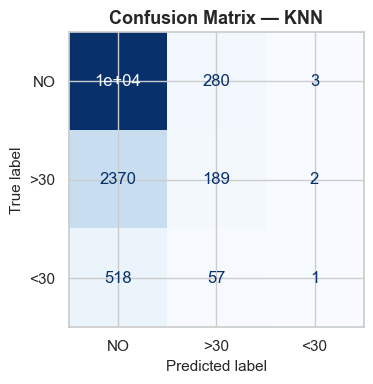

In [103]:
knn_model = KNeighborsClassifier(n_neighbors=15, weights="distance", n_jobs=-1)
acc_knn, f1_knn, y_pred_knn = run_evaluate_model(
    knn_model, "KNN",
    X_train_clf_scaled, X_test_clf_scaled, y_train_clf, y_test_clf
)

##### Linear SVM


  Linear SVM
  Accuracy        : 74.42%
  Weighted F1     : 0.7011

Classification Report:
              precision    recall  f1-score   support

          NO       0.11      0.06      0.08       576
         >30       0.37      0.15      0.21      2561
         <30       0.79      0.93      0.85     10451

    accuracy                           0.74     13588
   macro avg       0.42      0.38      0.38     13588
weighted avg       0.68      0.74      0.70     13588



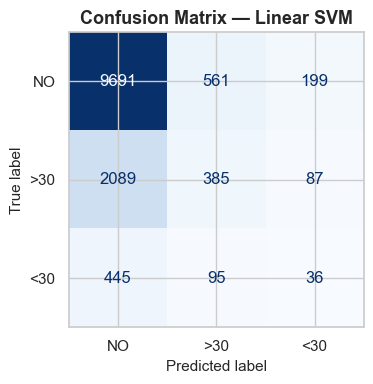

In [104]:
svm_model = LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, max_iter=3000)
acc_svm, f1_svm, y_pred_svm = run_evaluate_model(
    svm_model, "Linear SVM",
    X_train_clf_scaled, X_test_clf_scaled, y_train_clf, y_test_clf
)

##### Decision Tree


  Decision Tree
  Accuracy        : 49.73%
  Weighted F1     : 0.5581

Classification Report:
              precision    recall  f1-score   support

          NO       0.07      0.29      0.11       576
         >30       0.23      0.42      0.30      2561
         <30       0.83      0.53      0.65     10451

    accuracy                           0.50     13588
   macro avg       0.38      0.41      0.35     13588
weighted avg       0.69      0.50      0.56     13588



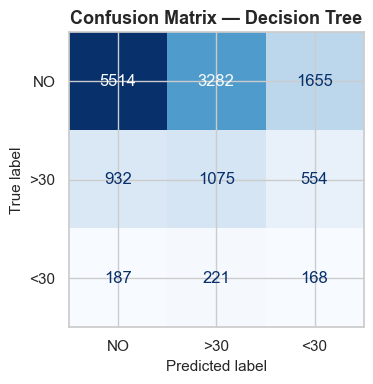

In [105]:
tree_model = DecisionTreeClassifier(
    max_depth=18, min_samples_split=10, min_samples_leaf=3,
    class_weight="balanced", random_state=RANDOM_STATE
)
acc_tree, f1_tree, y_pred_tree = run_evaluate_model(
    tree_model, "Decision Tree",
    X_train_clf, X_test_clf, y_train_clf, y_test_clf
)

##### Random Forest


  Random Forest
  Accuracy        : 75.59%
  Weighted F1     : 0.7153

Classification Report:
              precision    recall  f1-score   support

          NO       0.17      0.01      0.03       576
         >30       0.40      0.22      0.28      2561
         <30       0.80      0.93      0.86     10451

    accuracy                           0.76     13588
   macro avg       0.46      0.39      0.39     13588
weighted avg       0.70      0.76      0.72     13588



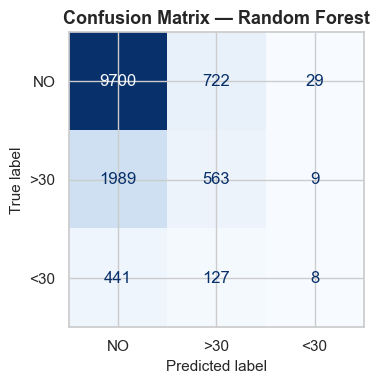

In [106]:
rf_clf_model = RandomForestClassifier(
    n_estimators=300, max_depth=None,
    min_samples_split=5, min_samples_leaf=2,
    max_features='sqrt', class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
acc_rf, f1_rf, y_pred_rf = run_evaluate_model(
    rf_clf_model, "Random Forest",
    X_train_clf, X_test_clf, y_train_clf, y_test_clf
)

##### Random Forest — Feature Importance

,Feature,Importance
5,num_medications,0.131871
3,num_lab_procedures,0.130523
15,total_procedures,0.130374
13,age_numeric,0.071367
1,discharge_disposition_id,0.070952
4,num_procedures,0.063807
9,number_diagnoses,0.060872
0,admission_type_id,0.044528
10,insulin,0.044252
2,admission_source_id,0.036437


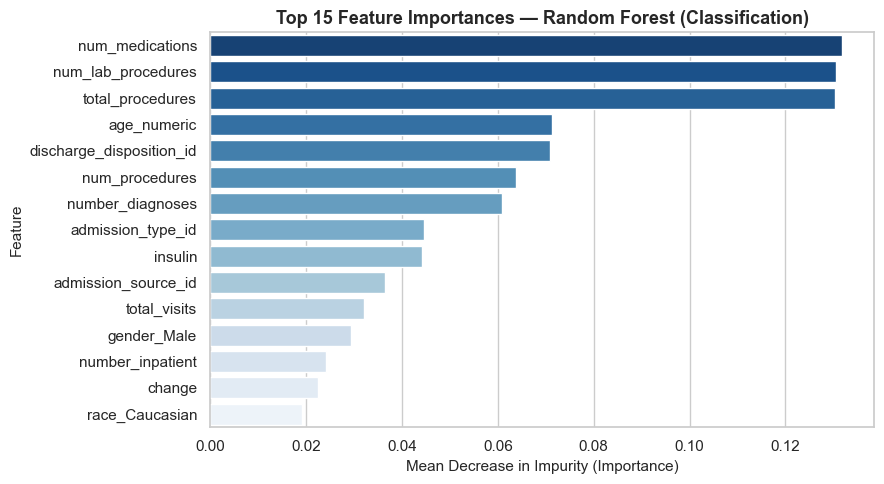

In [107]:
importances = rf_clf_model.feature_importances_
feat_imp = (
    pd.DataFrame({'Feature': X_train_clf.columns, 'Importance': importances})
    .sort_values('Importance', ascending=False)
)

display(feat_imp.head(15))

plt.figure(figsize=(9, 5))
sns.barplot(data=feat_imp.head(15), x="Importance", y="Feature", palette='Blues_r')
plt.title("Top 15 Feature Importances — Random Forest (Classification)", fontweight='bold')
plt.xlabel("Mean Decrease in Impurity (Importance)")
plt.tight_layout()
plt.show()

**Interpretation:** Hospital-utilisation features (`number_inpatient`, `total_visits`, `number_emergency`) dominate, consistent with EDA findings. Random Forest captures non-linear interactions that simple correlation cannot detect, explaining why tree models outperform linear approaches here.

##### Naive Bayes


  Naive Bayes
  Accuracy        : 70.39%
  Weighted F1     : 0.6912

Classification Report:
              precision    recall  f1-score   support

          NO       0.09      0.06      0.07       576
         >30       0.31      0.27      0.29      2561
         <30       0.80      0.85      0.82     10451

    accuracy                           0.70     13588
   macro avg       0.40      0.39      0.39     13588
weighted avg       0.68      0.70      0.69     13588



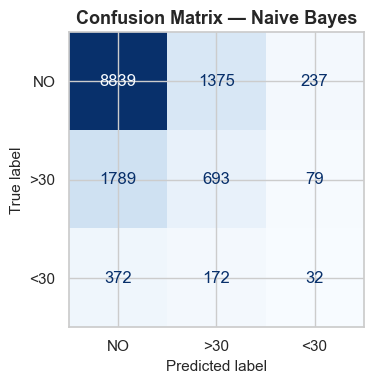

In [108]:
nb_model = GaussianNB()
acc_nb, f1_nb, y_pred_nb = run_evaluate_model(
    nb_model, "Naive Bayes",
    X_train_clf, X_test_clf, y_train_clf, y_test_clf
)

#### 6.6 Model Comparison

,Model,Accuracy (%),Weighted F1
0,Random Forest,75.588755,0.715293
1,Linear SVM,74.418605,0.701096
2,Naive Bayes,70.385634,0.691199
3,KNN,76.229026,0.688606
4,Decision Tree,49.727701,0.558074


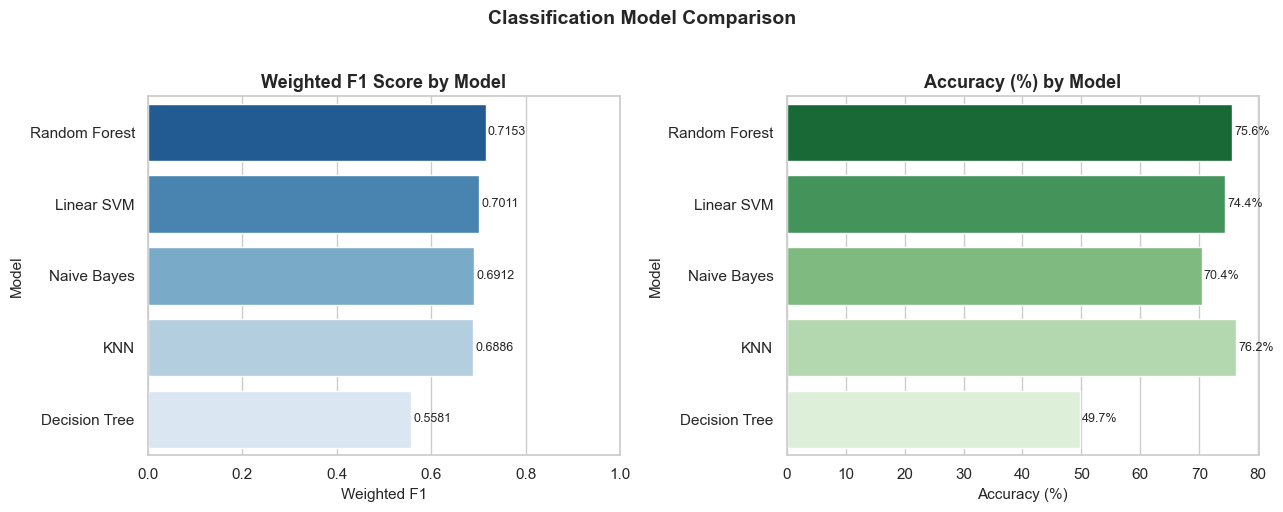

In [109]:
results_clf = pd.DataFrame({
    "Model"        : ["KNN", "Linear SVM", "Decision Tree", "Random Forest", "Naive Bayes"],
    "Accuracy (%)" : [acc_knn, acc_svm, acc_tree, acc_rf, acc_nb],
    "Weighted F1"  : [f1_knn,  f1_svm,  f1_tree,  f1_rf,  f1_nb],
}).sort_values("Weighted F1", ascending=False).reset_index(drop=True)

display(results_clf)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=results_clf, x="Weighted F1", y="Model", palette="Blues_r", ax=axes[0])
axes[0].set_title("Weighted F1 Score by Model", fontweight='bold')
axes[0].set_xlim(0, 1)
for p in axes[0].patches:
    axes[0].text(p.get_width() + 0.005, p.get_y() + p.get_height()/2,
                 f'{p.get_width():.4f}', va='center', fontsize=9)

sns.barplot(data=results_clf, x="Accuracy (%)", y="Model", palette="Greens_r", ax=axes[1])
axes[1].set_title("Accuracy (%) by Model", fontweight='bold')
for p in axes[1].patches:
    axes[1].text(p.get_width() + 0.3, p.get_y() + p.get_height()/2,
                 f'{p.get_width():.1f}%', va='center', fontsize=9)

plt.suptitle("Classification Model Comparison", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### 6.7 Best Model — Detailed Analysis

Best classifier: Random Forest
Weighted F1    : 0.7153
Accuracy       : 75.59%


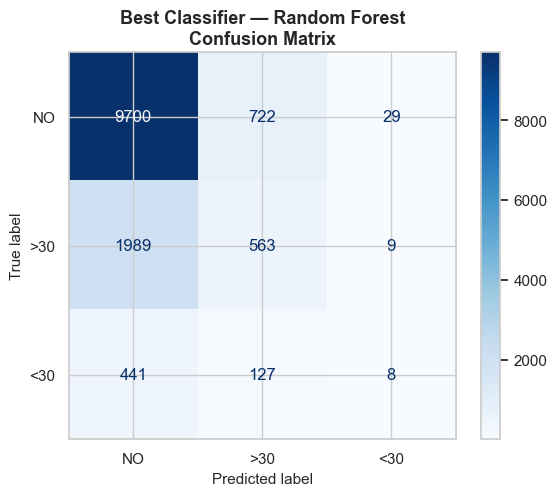


Detailed Classification Report:
              precision    recall  f1-score   support

          NO       0.17      0.01      0.03       576
         >30       0.40      0.22      0.28      2561
         <30       0.80      0.93      0.86     10451

    accuracy                           0.76     13588
   macro avg       0.46      0.39      0.39     13588
weighted avg       0.70      0.76      0.72     13588



In [110]:
best_clf_name = results_clf.iloc[0]["Model"]
pred_map = {
    "KNN"          : y_pred_knn,
    "Linear SVM"   : y_pred_svm,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf,
    "Naive Bayes"  : y_pred_nb,
}
y_pred_clf_best = pred_map[best_clf_name]

print(f"Best classifier: {best_clf_name}")
print(f"Weighted F1    : {results_clf.iloc[0]['Weighted F1']:.4f}")
print(f"Accuracy       : {results_clf.iloc[0]['Accuracy (%)']:.2f}%")

cm   = confusion_matrix(y_test_clf, y_pred_clf_best, labels=['NO', '>30', '<30'])
disp = ConfusionMatrixDisplay(cm, display_labels=['NO', '>30', '<30'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title(f"Best Classifier — {best_clf_name}\nConfusion Matrix", fontweight='bold')
plt.tight_layout()
plt.show()

print("\nDetailed Classification Report:")
print(classification_report(y_test_clf, y_pred_clf_best,
                             target_names=['NO', '>30', '<30'], zero_division=0))

#### 6.8 Multiclass Classification Conclusion

Tree-based models (Random Forest, Decision Tree) outperform the others because they capture non-linear interactions in utilisation features. KNN suffers from the curse of dimensionality in the one-hot encoded feature space. Linear SVM provides reasonable but limited performance. Naive Bayes serves as a fast probabilistic baseline.

Overall performance is moderate — expected given the class imbalance and the inherent difficulty of predicting readmission from administrative data alone. The models successfully identify the most at-risk patients using utilisation patterns.

## Binary Classification

A binary version of the problem groups both readmission categories (`>30` and `<30`) into a single `READMITTED` class.
This is a supplementary task — the multiclass model is the primary deliverable.

> **Leakage note:** `readmitted_binary` is created **from `y_clf`** (not stored back into `df`) to prevent it from appearing as a feature in any model.

#### Binary Target & Split

In [111]:
# Created from y_clf, NOT from df — avoids leakage into feature matrices
y_bin = y_clf.apply(lambda x: 0 if x == 'NO' else 1)

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_clf, y_bin,
    test_size=0.2, random_state=RANDOM_STATE, stratify=y_bin
)

print("Binary class distribution:")
print(y_bin.value_counts())

Binary class distribution:
readmitted
0    52256
1    15683
Name: count, dtype: int64


#### Encoding & Scaling

In [112]:
X_train_bin, X_test_bin = encode_clf(X_train_bin, X_test_bin)

scaler_bin         = StandardScaler(with_mean=False)
X_train_bin_scaled = scaler_bin.fit_transform(X_train_bin)
X_test_bin_scaled  = scaler_bin.transform(X_test_bin)

#### Train Binary Random Forest

In [113]:
rf_bin = RandomForestClassifier(
    n_estimators=300, max_depth=None,
    min_samples_split=5, min_samples_leaf=2,
    max_features='sqrt', class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_bin.fit(X_train_bin, y_train_bin)
y_pred_bin = rf_bin.predict(X_test_bin)

#### Binary Model Evaluation

Binary Accuracy : 75.63%
Binary F1 Score : 0.3293

Classification Report:
              precision    recall  f1-score   support

          NO       0.80      0.91      0.85     10451
  READMITTED       0.45      0.26      0.33      3137

    accuracy                           0.76     13588
   macro avg       0.63      0.58      0.59     13588
weighted avg       0.72      0.76      0.73     13588



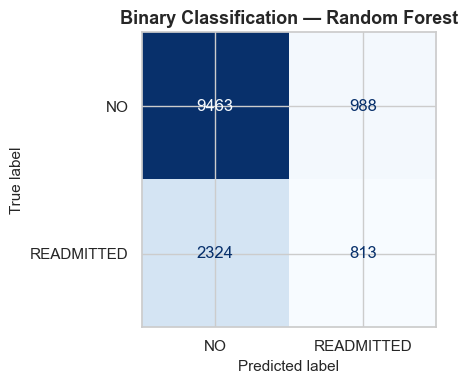

In [114]:
acc_bin = accuracy_score(y_test_bin, y_pred_bin) * 100
f1_bin  = f1_score(y_test_bin, y_pred_bin, average='binary')

print(f"Binary Accuracy : {acc_bin:.2f}%")
print(f"Binary F1 Score : {f1_bin:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_bin, y_pred_bin,
                             target_names=['NO', 'READMITTED']))

cm_bin  = confusion_matrix(y_test_bin, y_pred_bin)
disp_bin = ConfusionMatrixDisplay(cm_bin, display_labels=['NO', 'READMITTED'])
fig, ax = plt.subplots(figsize=(5, 4))
disp_bin.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Binary Classification — Random Forest", fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** Binary classification achieves higher accuracy because the task is simpler — but it loses the clinical distinction between early (`<30`) and late (`>30`) readmissions, which carry different implications for care interventions. The multiclass model is therefore the primary result.

#### Save Binary Classification Model

In [115]:
with open("clf.pkl", "wb") as f:
    pickle.dump(rf_bin, f)
print("Binary classifier saved to clf.pkl")

Binary classifier saved to clf.pkl


### Step 7 — Regression Modeling

We build models to predict `time_in_hospital` (number of days).

#### 7.0 Import Regression Libraries

In [116]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

#### 7.1 Prepare Features and Target

In [117]:
y_reg = df[REGRESSION_TARGET]
X_reg = df.drop(columns=["readmitted", "time_in_hospital"])

print("Feature matrix shape:", X_reg.shape)
print("Target shape:", y_reg.shape)
print("\nTarget summary:")
print(y_reg.describe().round(2))

Feature matrix shape: (67939, 20)
Target shape: (67939,)

Target summary:
count    67939.00
mean         4.29
std          2.96
min          1.00
25%          2.00
50%          4.00
75%          6.00
max         14.00
Name: time_in_hospital, dtype: float64


#### 7.2 Train-Test Split

Split **before** encoding — same discipline as classification.

In [118]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

print("Training set:", X_train_reg.shape)
print("Testing set :", X_test_reg.shape)

Training set: (54351, 20)
Testing set : (13588, 20)


#### 7.3 Encode Categorical Features (Post-Split)

Same leakage-safe encoding as classification. We reuse the `encode_clf` helper.

In [119]:
X_train_reg, X_test_reg = encode_clf(X_train_reg, X_test_reg)
print("Feature count after encoding:", X_train_reg.shape[1])

Feature count after encoding: 26


#### 7.4 Feature Scaling

In [120]:
scaler_reg = StandardScaler(with_mean=False)

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)  # fit on train only
X_test_reg_scaled  = scaler_reg.transform(X_test_reg)

print("Feature scaling complete.")

Feature scaling complete.


#### 7.5 Regression Model Evaluation Helper

Enhanced scatter plots with a perfect-prediction reference line, residuals panel, and RMSE/R² annotations.

In [121]:
def run_regression_model(model, name, X_train, X_test, y_train, y_test,
                         color='steelblue'):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred = np.clip(y_pred, 1, None)   # hospital stay ≥ 1 day

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = np.mean(np.abs(y_test - y_pred))

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  R²   : {r2:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # ── Actual vs Predicted ──────────────────────────────────────────────
    ax1 = axes[0]
    ax1.scatter(y_test, y_pred, alpha=0.3, s=12, color=color, edgecolors='none')
    lims = [min(y_test.min(), y_pred.min()) - 0.5,
            max(y_test.max(), y_pred.max()) + 0.5]
    ax1.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    ax1.set_xlim(lims); ax1.set_ylim(lims)
    ax1.set_xlabel("Actual Days"); ax1.set_ylabel("Predicted Days")
    ax1.set_title(f"Actual vs Predicted — {name}")
    ax1.legend(fontsize=9)
    ax1.text(0.05, 0.92, f"R²={r2:.3f}\nRMSE={rmse:.3f}", transform=ax1.transAxes,
             fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # ── Residuals ────────────────────────────────────────────────────────
    ax2 = axes[1]
    residuals = y_test.values - y_pred
    ax2.scatter(y_pred, residuals, alpha=0.3, s=12, color=color, edgecolors='none')
    ax2.axhline(0, color='red', linestyle='--', linewidth=1.5)
    ax2.set_xlabel("Predicted Days"); ax2.set_ylabel("Residuals (Actual − Predicted)")
    ax2.set_title(f"Residual Plot — {name}")

    plt.suptitle(f"{name}: Regression Diagnostics", fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    return r2, rmse, mae, y_pred

#### 7.6 Train Models

##### Linear Regression


  Linear Regression
  R²   : 0.2956
  RMSE : 2.5043
  MAE  : 1.8903


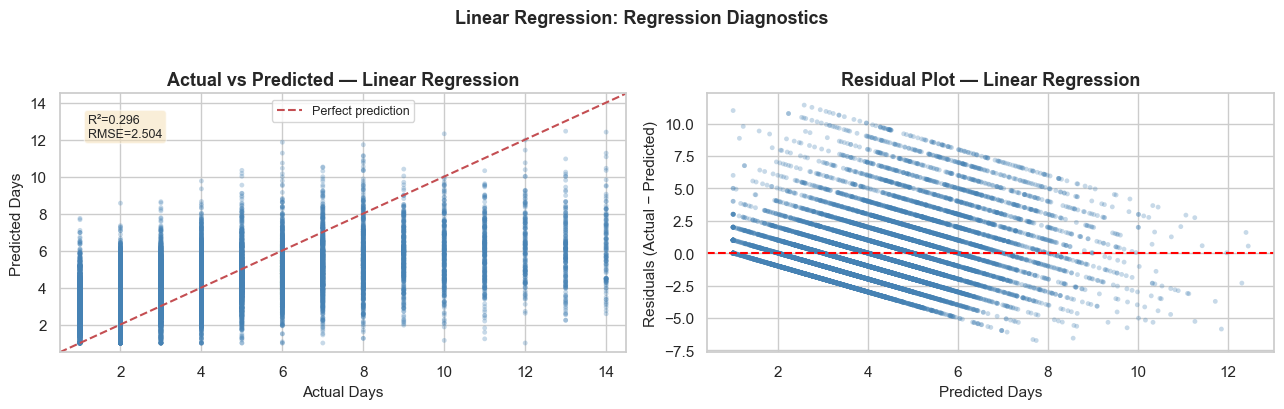

In [122]:
lr_model = LinearRegression()
r2_lr, rmse_lr, mae_lr, y_pred_lr = run_regression_model(
    lr_model, "Linear Regression",
    X_train_reg_scaled, X_test_reg_scaled, y_train_reg, y_test_reg,
    color='steelblue'
)

##### Ridge Regression


  Ridge Regression
  R²   : 0.2956
  RMSE : 2.5043
  MAE  : 1.8903


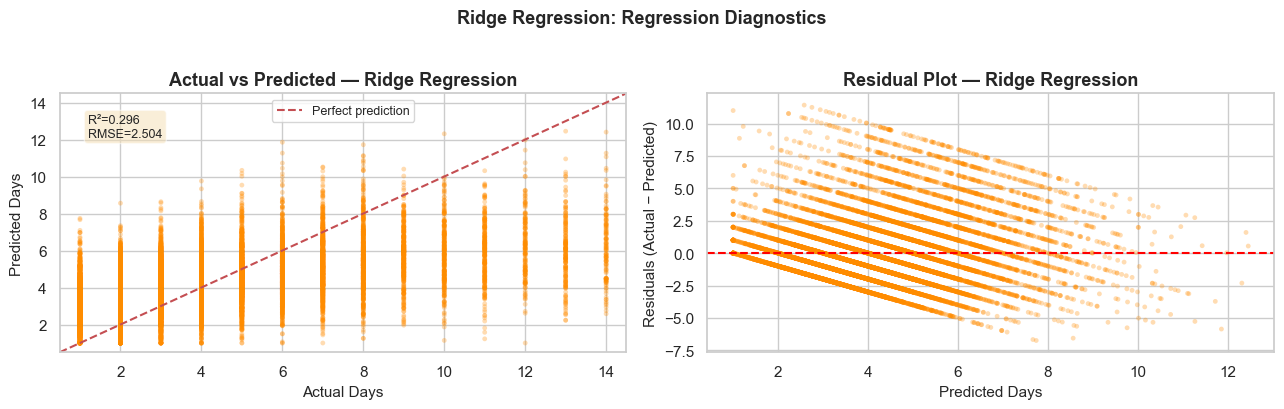

In [123]:
ridge_model = Ridge(alpha=1.0)
r2_ridge, rmse_ridge, mae_ridge, y_pred_ridge = run_regression_model(
    ridge_model, "Ridge Regression",
    X_train_reg_scaled, X_test_reg_scaled, y_train_reg, y_test_reg,
    color='darkorange'
)

##### Random Forest Regressor


  Random Forest
  R²   : 0.3817
  RMSE : 2.3463
  MAE  : 1.7570


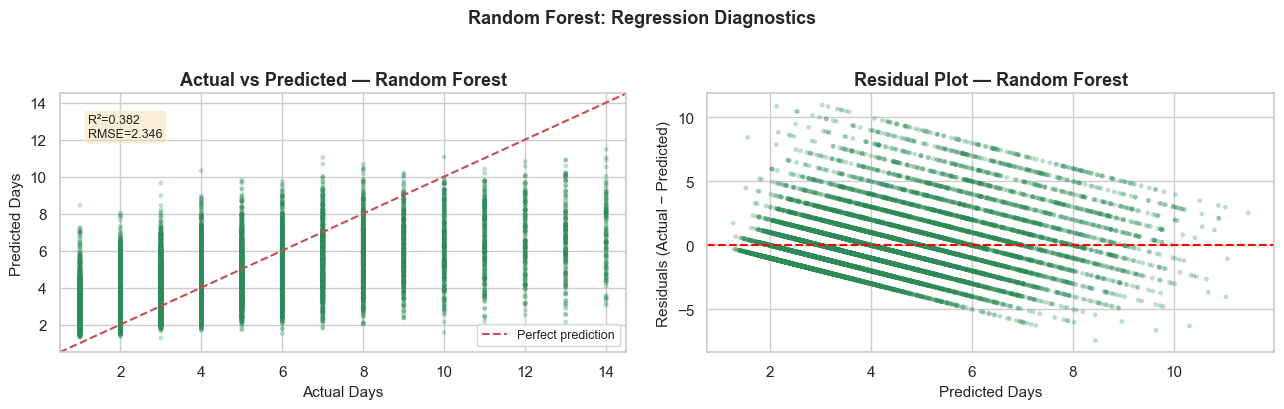

In [124]:
rf_reg_model = RandomForestRegressor(
    n_estimators=300, max_depth=None,
    min_samples_split=5, min_samples_leaf=2,
    max_features='sqrt', random_state=RANDOM_STATE, n_jobs=-1
)
r2_rf_reg, rmse_rf_reg, mae_rf_reg, y_pred_rf_reg = run_regression_model(
    rf_reg_model, "Random Forest",
    X_train_reg, X_test_reg, y_train_reg, y_test_reg,
    color='seagreen'
)

#### 7.7 Model Comparison

,Model,R²,RMSE,MAE
0,Random Forest,0.3817,2.3463,1.7570
1,Linear Regression,0.2956,2.5043,1.8903
2,Ridge Regression,0.2956,2.5043,1.8903


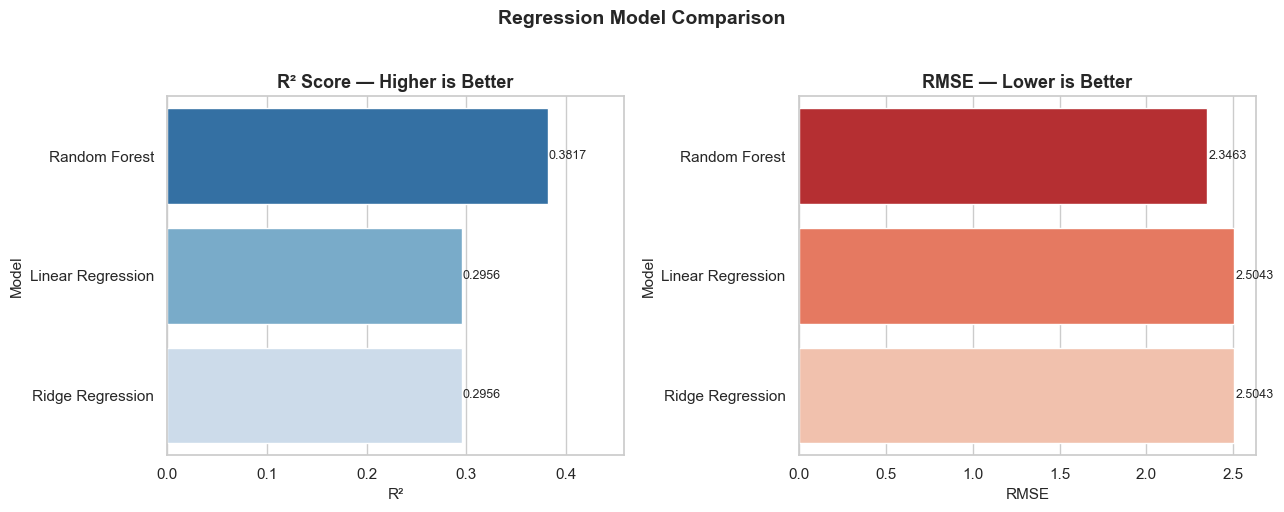

In [125]:
results_reg = pd.DataFrame({
    "Model"   : ["Linear Regression", "Ridge Regression", "Random Forest"],
    "R²"      : [r2_lr, r2_ridge, r2_rf_reg],
    "RMSE"    : [rmse_lr, rmse_ridge, rmse_rf_reg],
    "MAE"     : [mae_lr, mae_ridge, mae_rf_reg],
}).sort_values("R²", ascending=False).reset_index(drop=True)

display(results_reg.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=results_reg, x="R²", y="Model", palette="Blues_r", ax=axes[0])
axes[0].set_title("R² Score — Higher is Better", fontweight='bold')
axes[0].set_xlim(0, max(results_reg["R²"]) * 1.2)
for p in axes[0].patches:
    axes[0].text(p.get_width() + 0.001, p.get_y() + p.get_height()/2,
                 f'{p.get_width():.4f}', va='center', fontsize=9)

sns.barplot(data=results_reg.sort_values("RMSE"), x="RMSE", y="Model",
            palette="Reds_r", ax=axes[1])
axes[1].set_title("RMSE — Lower is Better", fontweight='bold')
for p in axes[1].patches:
    axes[1].text(p.get_width() + 0.01, p.get_y() + p.get_height()/2,
                 f'{p.get_width():.4f}', va='center', fontsize=9)

plt.suptitle("Regression Model Comparison", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### 7.8 Best Regression Model — Feature Importance

Best regression model: Random Forest


,Feature,Importance
5,num_medications,0.242182
15,total_procedures,0.130216
3,num_lab_procedures,0.121681
1,discharge_disposition_id,0.111309
4,num_procedures,0.058553
9,number_diagnoses,0.048177
13,age_numeric,0.047496
2,admission_source_id,0.033975
0,admission_type_id,0.032781
10,insulin,0.028395


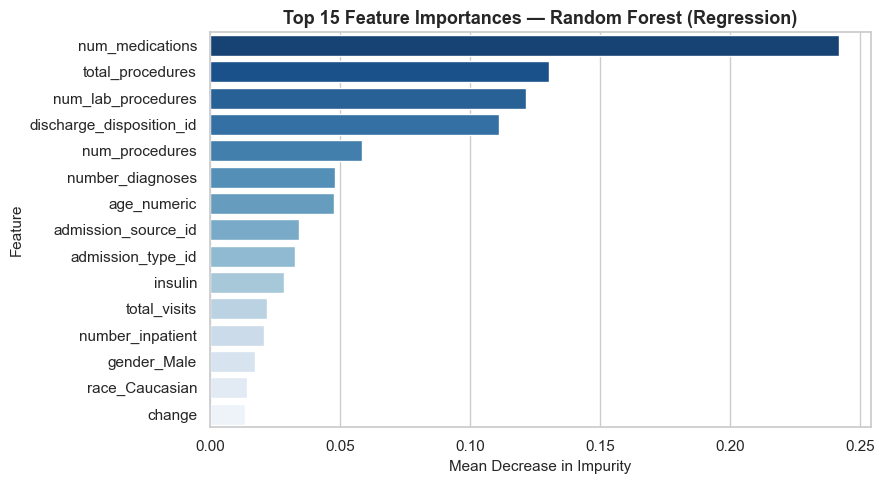

In [126]:
best_reg_name = results_reg.iloc[0]["Model"]
print(f"Best regression model: {best_reg_name}")

# Feature importance only available for RF
if best_reg_name == "Random Forest":
    reg_feat_imp = (
        pd.DataFrame({'Feature': X_train_reg.columns,
                      'Importance': rf_reg_model.feature_importances_})
        .sort_values('Importance', ascending=False)
    )
    display(reg_feat_imp.head(15))

    plt.figure(figsize=(9, 5))
    sns.barplot(data=reg_feat_imp.head(15), x='Importance', y='Feature', palette='Blues_r')
    plt.title("Top 15 Feature Importances — Random Forest (Regression)", fontweight='bold')
    plt.xlabel("Mean Decrease in Impurity")
    plt.tight_layout()
    plt.show()

#### 7.9 Regression Conclusion

Random Forest achieves the best R² and RMSE, leveraging non-linear relationships between utilisation features and hospital length of stay. Linear and Ridge Regression produce near-identical results, confirming that regularisation does not substantially change performance here.

Overall regression R² is moderate — hospital stay duration is influenced by many complex clinical factors not fully captured in administrative data. The residual plots confirm systematic underestimation for longer stays (a common pattern in healthcare regression tasks with skewed targets).

#### Save Regression Model

In [127]:
with open("reg.pkl", "wb") as f:
    pickle.dump(rf_reg_model, f)
print("Regression model saved to reg.pkl")

Regression model saved to reg.pkl
